In [30]:
# Cell 1
import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [31]:
# Cell 2
url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"

print("Downloading dataset (this may take a moment)...")
urllib.request.urlretrieve(url, file_name)
print("Download complete.")

print("Parsing JSONL.GZ file...")
data = []

# Open the compressed file and read line by line
with gzip.open(file_name, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Limiting to 100,000 rows to prevent RAM overload.
        # Remove or increase this limit if your machine has high memory.
        #if i >= 100000:
        #    break
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records.")
df.head(3)

Download complete.
Parsing JSONL.GZ file...
Loaded 701528 records.


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [32]:
# Cell 3 (Updated with Balancing Pipeline and 3-Star Count)
from sklearn.utils import resample
import pandas as pd

def preprocess_and_balance_data(df, random_seed=42):
    # Combine title and text to give models maximum context
    df = df.copy()
    df['full_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

    # Drop rows that are completely empty
    df = df[df['full_text'].str.strip() != ""]

    # Count how many 3-star reviews exist before dropping them
    num_dropped_3_star = len(df[df['rating'] == 3.0])

    # Filter out 3-star reviews for binary classification
    df = df[df['rating'] != 3.0]

    # Create binary sentiment labels (4 & 5 stars -> 1, 1 & 2 stars -> 0)
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)

    # Separate the reviews into majority and minority classes
    positive_reviews = df[df['sentiment'] == 1]
    negative_reviews = df[df['sentiment'] == 0]

    min_class_size = min(len(positive_reviews), len(negative_reviews))

    # Downsample the classes to match the minimum class size
    pos_downsampled = resample(positive_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    neg_downsampled = resample(negative_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    # Combine the downsampled classes back together
    balanced_df = pd.concat([pos_downsampled, neg_downsampled])

    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

    # We now return the dropped count as well
    return balanced_df, pos_downsampled, neg_downsampled, num_dropped_3_star

print("Balancing the dataset...")
balanced_df, pos_df, neg_df, dropped_count = preprocess_and_balance_data(df)

print(f"Dataset balanced successfully!")
print(f"Total 3-star (neutral) reviews dropped: {dropped_count}")
print(f"Total reviews kept for training: {len(balanced_df)}")
print(f"Positive reviews: {len(pos_df)} | Negative reviews: {len(neg_df)}")

# Extract the features (X) and labels (y) for Cell 4 to use
texts = balanced_df['full_text'].values
labels = balanced_df['sentiment'].values

Balancing the dataset...
Dataset balanced successfully!
Total 3-star (neutral) reviews dropped: 56307
Total reviews kept for training: 290228
Positive reviews: 145114 | Negative reviews: 145114


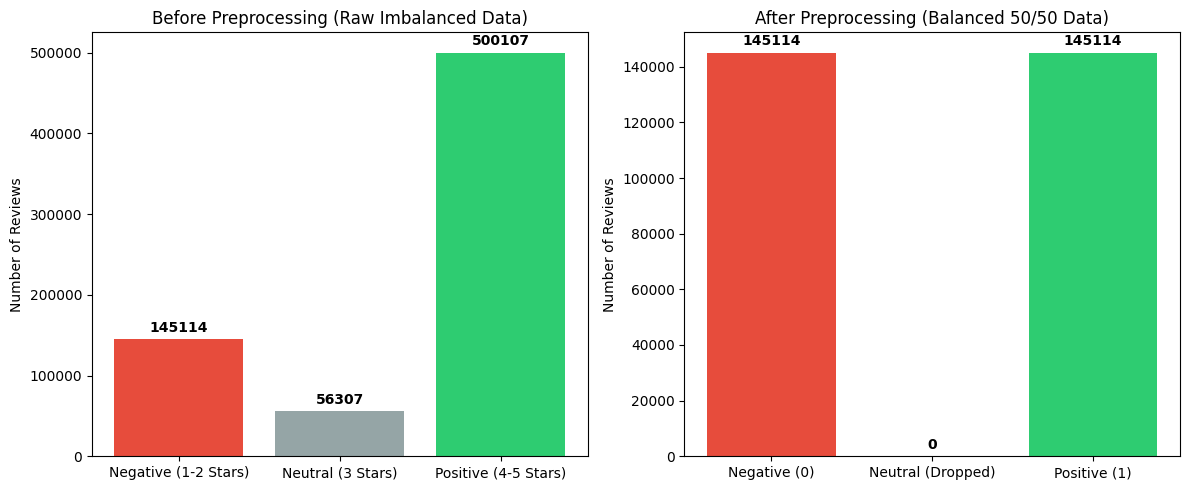

In [33]:
# Cell 3.5 (Visualization of Class Distributions)
import matplotlib.pyplot as plt

# --- Calculate "Before" Distribution from raw df ---
# Grouping the raw 1-5 star ratings into our 3 categories
raw_neg = len(df[df['rating'].isin([1.0, 2.0])])
raw_neu = len(df[df['rating'] == 3.0])
raw_pos = len(df[df['rating'].isin([4.0, 5.0])])

# --- Calculate "After" Distribution from balanced_df ---
# The balanced dataframe uses 0 for Negative and 1 for Positive
bal_neg = len(balanced_df[balanced_df['sentiment'] == 0])
bal_neu = 0  # We explicitly dropped all neutral reviews
bal_pos = len(balanced_df[balanced_df['sentiment'] == 1])

# --- Set up the side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Before Preprocessing
categories_before = ['Negative (1-2 Stars)', 'Neutral (3 Stars)', 'Positive (4-5 Stars)']
counts_before = [raw_neg, raw_neu, raw_pos]
axes[0].bar(categories_before, counts_before, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Before Preprocessing (Raw Imbalanced Data)')
axes[0].set_ylabel('Number of Reviews')
# Add value labels on top of the bars
for i, v in enumerate(counts_before):
    axes[0].text(i, v + (max(counts_before)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: After Preprocessing
categories_after = ['Negative (0)', 'Neutral (Dropped)', 'Positive (1)']
counts_after = [bal_neg, bal_neu, bal_pos]
axes[1].bar(categories_after, counts_after, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('After Preprocessing (Balanced 50/50 Data)')
axes[1].set_ylabel('Number of Reviews')
# Add value labels on top of the bars
for i, v in enumerate(counts_after):
    axes[1].text(i, v + (max(counts_after)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Cell 4
# Split into 75% training data and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)

# Text processing hyperparameters
vocab_size = 15000  # Number of unique words to keep
max_length = 120    # Max length of a review
trunc_type = 'post' # Truncate long reviews at the end
padding_type = 'post'# Pad short reviews at the end
oov_tok = "<OOV>"   # Token for Out Of Vocabulary words

print("Fitting the tokenizer...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert text into padded sequences of numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Training data shape: {train_padded.shape}")
print(f"Testing data shape: {test_padded.shape}")

Fitting the tokenizer...
Training data shape: (217671, 120)
Testing data shape: (72557, 120)


In [35]:
# Cell 5
embedding_dim = 64

model = Sequential([
    # Turns positive integers into dense vectors of fixed size
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM to capture contextual dependencies
    Bidirectional(LSTM(64, return_sequences=True)),

    # Condense the output to the most important features
    GlobalMaxPooling1D(),

    # Fully connected layers with Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer: Sigmoid returns a probability between 0 and 1
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Cell 6
num_epochs = 6
batch_size = 256

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Starting model training...")
history = model.fit(
    train_padded, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(test_padded, y_test),
    callbacks=[early_stopping]
)

Starting model training...
Epoch 1/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9296 - loss: 0.1862 - val_accuracy: 0.9534 - val_loss: 0.1262
Epoch 2/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9615 - loss: 0.1109 - val_accuracy: 0.9575 - val_loss: 0.1161
Epoch 3/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9697 - loss: 0.0899 - val_accuracy: 0.9597 - val_loss: 0.1151
Epoch 4/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9754 - loss: 0.0749 - val_accuracy: 0.9588 - val_loss: 0.1233
Epoch 5/6
851/851 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9805 - loss: 0.0618 - val_accuracy: 0.9577 - val_loss: 0.1243


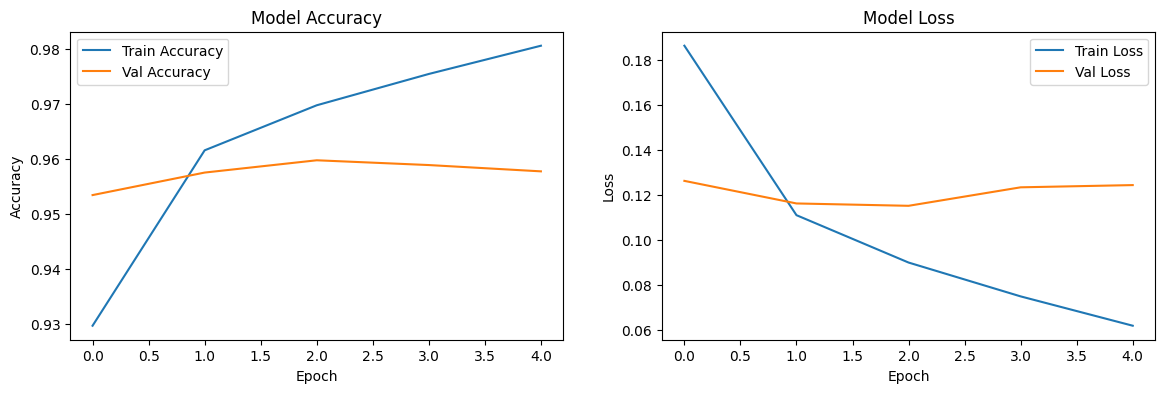

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive (Confidence Score: 0.9999)

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative (Confidence Score: 0.0001)

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative (Confidence Score: 0.0993)



In [37]:
# Cell 7
# Plot Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()

# --- Custom Review Tester ---
def predict_sentiment(review_text):
    # Process the raw text into the format the model expects
    seq = tokenizer.texts_to_sequences([review_text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Predict
    pred = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Confidence Score: {pred:.4f})\n")

# Try it out with your own phrases!
predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")

In [1]:
#Logistic Regression model

#cell 1 - imports

import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")
 

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils import resample
from wordcloud import WordCloud
 
nltk.download("punkt",        quiet=True)
nltk.download("stopwords",    quiet=True)
nltk.download("wordnet",      quiet=True)
nltk.download("punkt_tab",    quiet=True)
 
print("All libraries loaded successfully!")
print(f"Scikit-learn is ready for Logistic Regression.")

All libraries loaded successfully!
Scikit-learn is ready for Logistic Regression.


In [2]:
#cell 2

url       = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"
 
print("Downloading dataset (this may take a moment)...")
urllib.request.urlretrieve(url, file_name)
print("Download complete.")
 
print("Streaming JSONL.GZ file into a balanced dataset...")
 
TARGET_PER_CLASS = 50_000   #50k positive + 50k negative = 100k total
chunk_size       = 10_000
 
pos_list, neg_list = [], []
 
with gzip.open(file_name, "rt", encoding="utf-8") as f:
    chunk = []
    for i, line in enumerate(f):
        chunk.append(json.loads(line))
        if len(chunk) == chunk_size:
            cdf     = pd.DataFrame(chunk)[["text", "rating"]].dropna()
            pos_list.append(cdf[cdf["rating"] >= 4])
            neg_list.append(cdf[cdf["rating"] <= 2])
            chunk = []
            cur_pos = sum(len(c) for c in pos_list)
            cur_neg = sum(len(c) for c in neg_list)
            print(f"  Collected: {cur_pos:,} Pos | {cur_neg:,} Neg ...", end="\r")
            if cur_pos >= TARGET_PER_CLASS and cur_neg >= TARGET_PER_CLASS:
                print("\n  Target reached! Stopping stream.")
                break
 
df_pos = pd.concat(pos_list).iloc[:TARGET_PER_CLASS]
df_neg = pd.concat(neg_list).iloc[:TARGET_PER_CLASS]
 
df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
df["label"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)
 
#3 star reviews that were naturally excluded
with gzip.open(file_name, "rt", encoding="utf-8") as f:
    neutral_count = sum(1 for line in f if json.loads(line).get("rating") == 3.0)
 
print(f"\nDataset loaded!")
print(f"  3-star (neutral) reviews excluded : {neutral_count:,}")
print(f"  Positive reviews (4-5 stars)      : {len(df_pos):,}")
print(f"  Negative reviews (1-2 stars)      : {len(df_neg):,}")
print(f"  Total balanced dataset            : {len(df):,}")
df.head(3)
 

Download complete.
Streaming JSONL.GZ file into a balanced dataset...
  Collected: 205,153 Pos | 50,289 Neg ...
  Target reached! Stopping stream.

Dataset loaded!
  3-star (neutral) reviews excluded : 56,307
  Positive reviews (4-5 stars)      : 50,000
  Negative reviews (1-2 stars)      : 50,000
  Total balanced dataset            : 100,000


,text,rating,label
0,It wasnt a lot of money but its enuf to be mad...,1.0,0
1,Didn’t like the 2 shapes,1.0,0
2,I suffer from having hard skin around the heel...,4.0,1


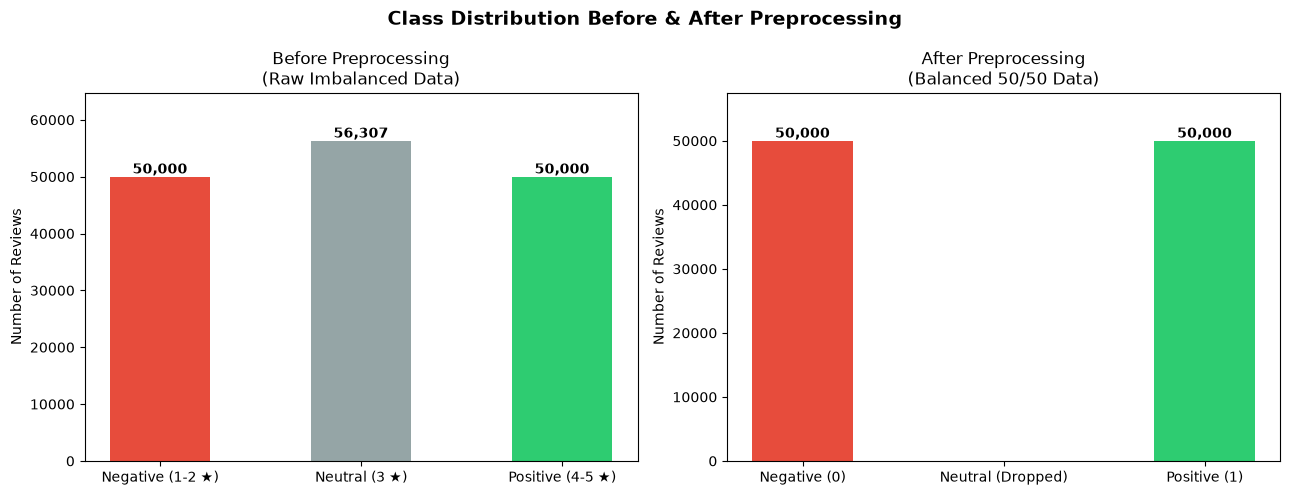

In [3]:
# cell 3 - Raw counts (approximate from what we streamed)
raw_pos = len(df_pos)
raw_neg = len(df_neg)
raw_neu = neutral_count
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Distribution Before & After Preprocessing", fontsize=14, fontweight="bold")
 
cats_before  = ["Negative (1-2 ★)", "Neutral (3 ★)", "Positive (4-5 ★)"]
cnts_before  = [raw_neg, raw_neu, raw_pos]
bars0 = axes[0].bar(cats_before, cnts_before, color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.5)
axes[0].set_title("Before Preprocessing\n(Raw Imbalanced Data)", fontsize=12)
axes[0].set_ylabel("Number of Reviews")
axes[0].set_ylim(0, max(cnts_before) * 1.15)
for bar, val in zip(bars0, cnts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cnts_before) * 0.01,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=10)

cats_after = ["Negative (0)", "Neutral (Dropped)", "Positive (1)"]
cnts_after = [len(df[df["label"] == 0]), 0, len(df[df["label"] == 1])]
bars1 = axes[1].bar(cats_after, cnts_after, color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.5)
axes[1].set_title("After Preprocessing\n(Balanced 50/50 Data)", fontsize=12)
axes[1].set_ylabel("Number of Reviews")
axes[1].set_ylim(0, max(cnts_after) * 1.15)
for bar, val in zip(bars1, cnts_after):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cnts_after) * 0.01,
                     f"{val:,}", ha="center", fontweight="bold", fontsize=10)
 
plt.tight_layout()
plt.show()
 

In [4]:
#cell 4 - Preprocessing

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))
 
def preprocess_for_logreg(text: str) -> str:
    """
    Full preprocessing pipeline tailored for TF-IDF + Logistic Regression.
 
    Steps
    -----
    1. Lowercase
    2. Remove URLs, HTML tags, punctuation, digits
    3. Tokenize
    4. Remove stopwords  (important: reduces TF-IDF noise)
    5. Lemmatize         (collapses word forms → smaller, cleaner vocab)
    6. Remove very short tokens (< 3 chars)
 
    Returns
    -------
    str : cleaned text ready for TfidfVectorizer
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+",    " ", text)   # URLs
    text = re.sub(r"<[^>]+>",           " ", text)   # HTML tags
    text = re.sub(r"[^a-z\s]",          " ", text)   # non-alpha
    text = re.sub(r"\s+",               " ", text).strip()
 
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
 
    return " ".join(tokens)
 
 
print("Applying preprocessing pipeline to all reviews...")
print("(Lowercase → Remove noise → Tokenize → Stopwords → Lemmatize)\n")
 
df["text_clean"] = df["text"].apply(preprocess_for_logreg)
 
print("BEFORE → AFTER examples:")
print("─" * 70)
for i in [0, 1, 2]:
    print(f"[RAW]   {df['text'].iloc[i][:120]}")
    print(f"[CLEAN] {df['text_clean'].iloc[i][:120]}")
    print()
 

Applying preprocessing pipeline to all reviews...
(Lowercase → Remove noise → Tokenize → Stopwords → Lemmatize)

BEFORE → AFTER examples:
──────────────────────────────────────────────────────────────────────
[RAW]   It wasnt a lot of money but its enuf to be mad that they split the hair that should be on one extention and made it into
[CLEAN] wasnt lot money enuf mad split hair one extention made happy enuf wanted like said barely enuf one piece soft color grea

[RAW]   Didn’t like the 2 shapes
[CLEAN] like shape

[RAW]   I suffer from having hard skin around the heel and bottom area of my foot.  It gets real hard and I have to soften it up
[CLEAN] suffer hard skin around heel bottom area foot get real hard soften hot water epson salt use stone scrub away skin harden



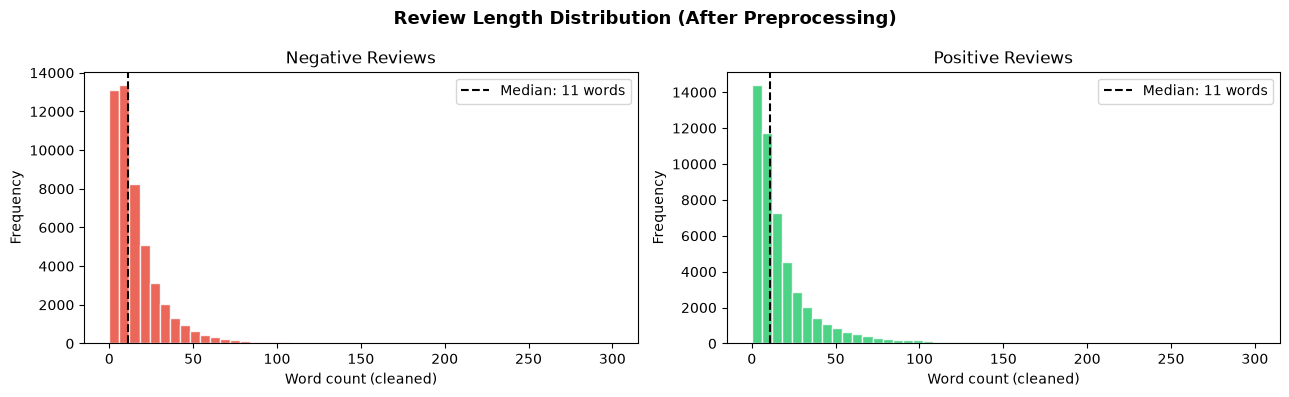

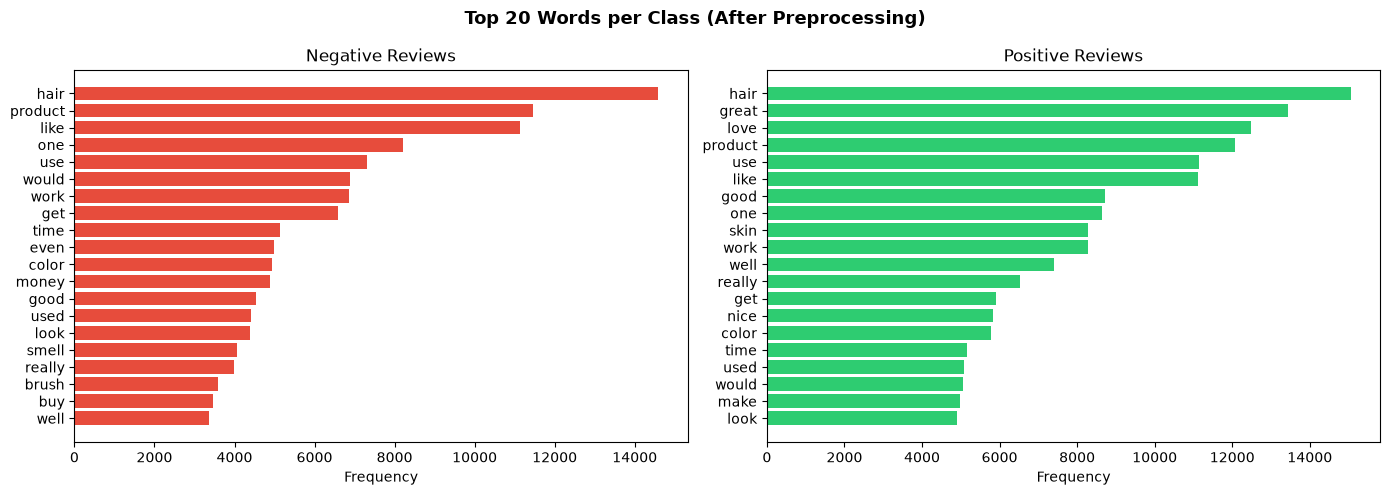

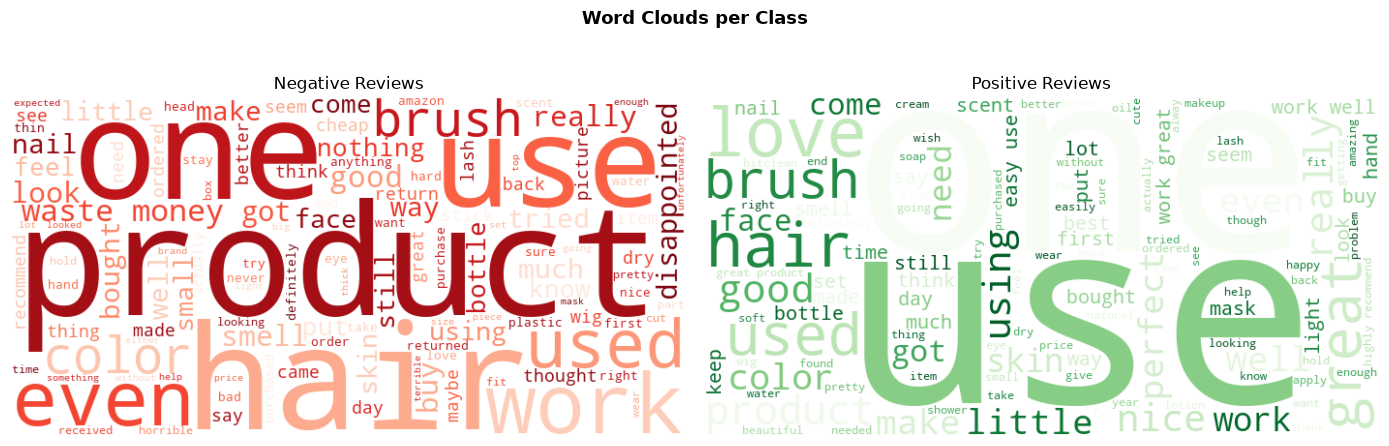

In [5]:
#cell 5 

df["length_raw"]   = df["text"].str.split().str.len()
df["length_clean"] = df["text_clean"].str.split().str.len()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Review Length Distribution (After Preprocessing)", fontsize=13, fontweight="bold")
 
for ax, (label, name, color) in zip(axes, [(0, "Negative", "#e74c3c"), (1, "Positive", "#2ecc71")]):
    subset = df[df["label"] == label]["length_clean"].clip(upper=300)
    ax.hist(subset, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(subset.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {subset.median():.0f} words")
    ax.set_title(f"{name} Reviews")
    ax.set_xlabel("Word count (cleaned)")
    ax.set_ylabel("Frequency")
    ax.legend()
 
plt.tight_layout()
plt.show()

from collections import Counter
 
def top_words(texts, n=20):
    words = [w for t in texts for w in t.split() if len(w) >= 3]
    return Counter(words).most_common(n)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top 20 Words per Class (After Preprocessing)", fontsize=13, fontweight="bold")
 
for ax, (label, name, color) in zip(axes, [(0, "Negative", "#e74c3c"), (1, "Positive", "#2ecc71")]):
    pairs = top_words(df[df["label"] == label]["text_clean"])
    words, freqs = zip(*pairs)
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=color)
    ax.set_title(f"{name} Reviews")
    ax.set_xlabel("Frequency")
 
plt.tight_layout()
plt.show()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Word Clouds per Class", fontsize=13, fontweight="bold")
 
for ax, (label, name, cmap) in zip(axes, [(0, "Negative", "Reds"), (1, "Positive", "Greens")]):
    corpus = " ".join(df[df["label"] == label]["text_clean"].tolist())
    wc = WordCloud(width=700, height=350, background_color="white",
                   colormap=cmap, max_words=120).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{name} Reviews", fontsize=12)
 
plt.tight_layout()
plt.show()
 

In [6]:
#cell 6 - TF - IDF

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text_clean"], df["label"],
    test_size=0.25, random_state=42, stratify=df["label"]
)
 
print(f"Train size : {len(X_train_raw):,}")
print(f"Test size  : {len(X_test_raw):,}")

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   
    max_features=15_000,  
    min_df=3,             
    sublinear_tf=True,    
)
 
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)
 
print(f"\nTF-IDF matrix shape:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")

Train size : 75,000
Test size  : 25,000

TF-IDF matrix shape:
  Train : (75000, 15000)
  Test  : (25000, 15000)


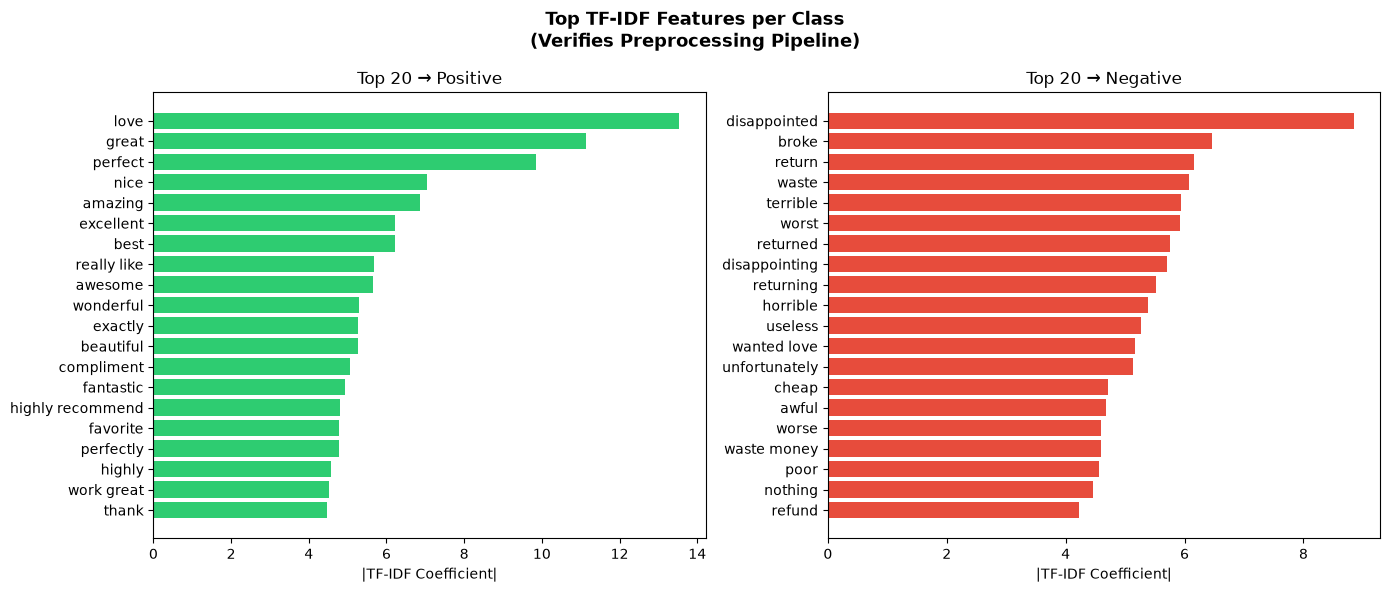

Pipeline check: do the features above make intuitive sense?
Positive top words should include: great, love, perfect, amazing ...
Negative top words should include: return, waste, broke, terrible ...


In [7]:
#cell 7

probe = LogisticRegression(max_iter=500, C=1.0, solver="lbfgs")
probe.fit(X_train_tfidf, y_train)
 
feature_names = np.array(vectorizer.get_feature_names_out())
coefs         = probe.coef_[0]
n             = 20
 
top_pos_idx = np.argsort(coefs)[-n:][::-1]
top_neg_idx = np.argsort(coefs)[:n]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Top TF-IDF Features per Class\n(Verifies Preprocessing Pipeline)", fontsize=13, fontweight="bold")
 
for ax, idx, title, color in [
    (axes[0], top_pos_idx, "Top 20 → Positive", "#2ecc71"),
    (axes[1], top_neg_idx, "Top 20 → Negative", "#e74c3c"),
]:
    ax.barh(feature_names[idx][::-1], np.abs(coefs[idx][::-1]), color=color)
    ax.set_title(title)
    ax.set_xlabel("|TF-IDF Coefficient|")
 
plt.tight_layout()
plt.show()
 
print("Pipeline check: do the features above make intuitive sense?")
print("Positive top words should include: great, love, perfect, amazing ...")
print("Negative top words should include: return, waste, broke, terrible ...")
 

In [8]:
#cell 8 - training


print("Training Logistic Regression...")
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",   #handles any residual imbalance
    random_state=42,
)
lr_model.fit(X_train_tfidf, y_train)
print("Training complete!")
 
y_pred  = lr_model.predict(X_test_tfidf)
y_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
 
print("\n--- MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Training Logistic Regression...
Training complete!

--- MODEL PERFORMANCE ---
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88     12500
    Positive       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



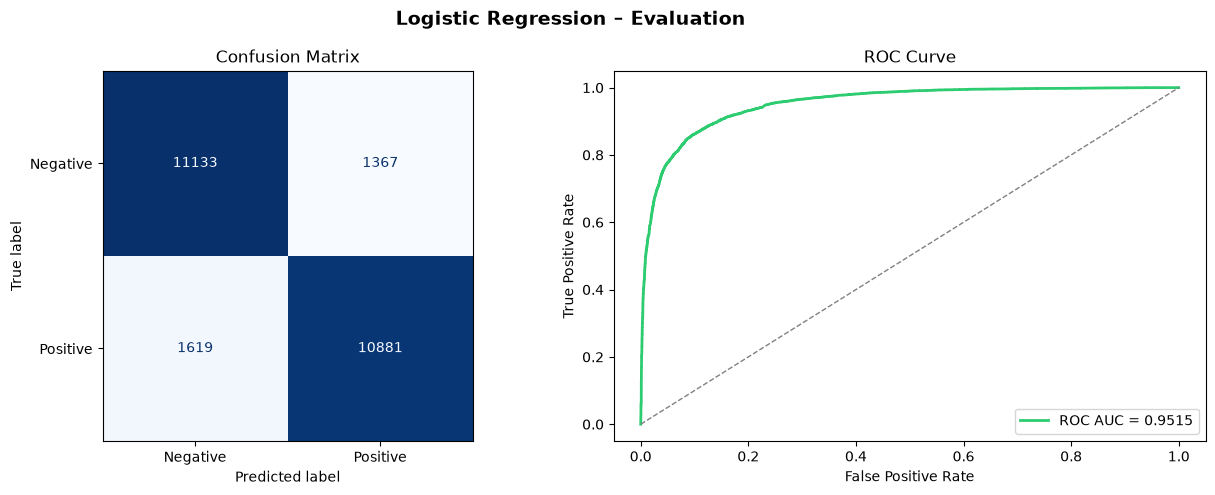

In [9]:
#cell 9

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression – Evaluation", fontsize=14, fontweight="bold")
 
#confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")
 
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#2ecc71", lw=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
 
plt.tight_layout()
plt.show()
 